# 🚗 Driver Behavior Anomaly Detection
## Notebook 01 — Data Exploration (Step 1)

**Goal:** Load the sensor CSV and understand what we're working with.

Each row = one sensor reading at a specific timestamp  
Columns: `AccX, AccY, AccZ` (m/s²) · `GyroX, GyroY, GyroZ` (rad/s) · `Timestamp` · `Class`

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Config (copy from 00 for standalone use)
DATA_LABELED   = "test_motion_data.csv"
OUTPUT_DIR     = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
SENSOR_COLS    = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"]
CLASS_COLORS   = {"NORMAL": "#2ecc71", "AGGRESSIVE": "#e74c3c", "SLOW": "#3498db"}
CLASS_NAMES    = ["NORMAL", "AGGRESSIVE", "SLOW"]

print("✅ Libraries loaded")

✅ Libraries loaded


### 1.1 — Load the CSV

In [2]:
df = pd.read_csv(DATA_LABELED)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:", df.isnull().sum().sum())
print("\nClass counts:")
print(df['Class'].value_counts())
df.head()

Shape: (3084, 8)

Columns: ['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ', 'Class', 'Timestamp']

Missing values: 0

Class counts:
Class
SLOW          1273
NORMAL         997
AGGRESSIVE     814
Name: count, dtype: int64


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Class,Timestamp
0,0.758194,-0.217791,0.457263,0.000000,0.000000,0.000000,AGGRESSIVE,818922
1,0.667560,-0.038610,0.231416,-0.054367,-0.007712,0.225257,AGGRESSIVE,818923
2,2.724449,-7.584121,2.390926,0.023824,0.013668,-0.038026,AGGRESSIVE,818923
3,2.330950,-7.621754,2.529024,0.056810,-0.180587,-0.052076,AGGRESSIVE,818924
4,2.847215,-6.755621,2.224640,-0.031765,-0.035201,0.035277,AGGRESSIVE,818924


### 1.2 — Basic statistics

In [3]:
df[SENSOR_COLS].describe().round(4)

,AccX,AccY,AccZ,GyroX,GyroY,GyroZ
count,3084.0000,3084.0000,3084.0000,3084.0000,3084.0000,3084.0000
mean,0.1062,-0.1318,0.0450,0.0032,0.0015,0.0115
std,0.9681,0.9044,0.9976,0.0666,0.1210,0.1135
min,-4.8542,-7.6218,-6.1070,-0.5150,-1.3095,-0.9763
25%,-0.4089,-0.6259,-0.4614,-0.0244,-0.0457,-0.0270
50%,0.0519,-0.0969,0.0542,0.0012,-0.0010,0.0023
75%,0.5791,0.3931,0.5751,0.0281,0.0436,0.0359
max,5.8650,4.3088,5.5640,1.4905,1.7076,0.7194


In [4]:
# Per-class statistics — do classes differ in sensor values?
print("Mean sensor values per driving class:")
df.groupby('Class')[SENSOR_COLS].mean().round(4)

Mean sensor values per driving class:


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ
Class,,,,,,
AGGRESSIVE,0.2436,-0.3244,0.0520,0.0020,0.0025,0.0173
NORMAL,0.0431,-0.1344,0.0548,0.0058,0.0051,0.0116
SLOW,0.0679,-0.0066,0.0329,0.0019,-0.0021,0.0076


### 1.3 — Class distribution plot

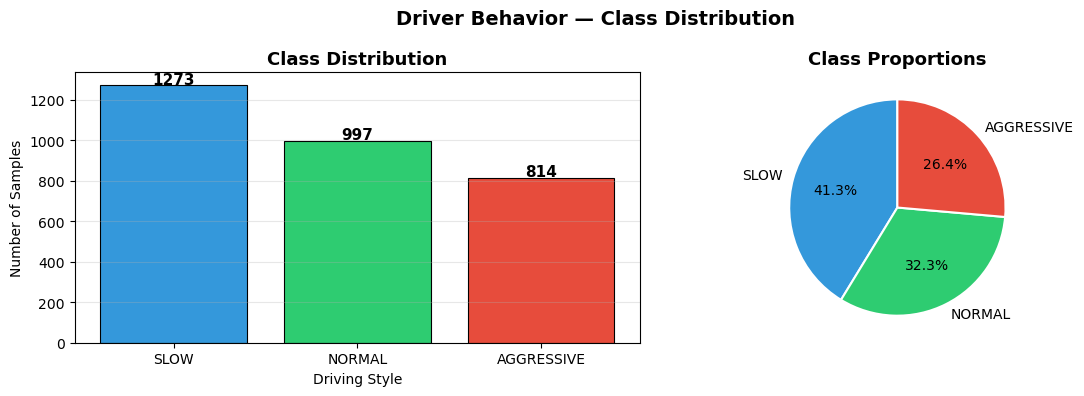

📊 Note: Dataset is imbalanced — SLOW > NORMAL > AGGRESSIVE


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['Class'].value_counts()
colors = [CLASS_COLORS[c] for c in counts.index]

# Bar chart
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 str(cnt), ha='center', fontweight='bold', fontsize=11)
axes[0].set_title("Class Distribution", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Driving Style")
axes[0].set_ylabel("Number of Samples")
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title("Class Proportions", fontsize=13, fontweight='bold')

plt.suptitle("Driver Behavior — Class Distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Note: Dataset is imbalanced — SLOW > NORMAL > AGGRESSIVE")

### 1.4 — Raw sensor signals over time (coloured by class)

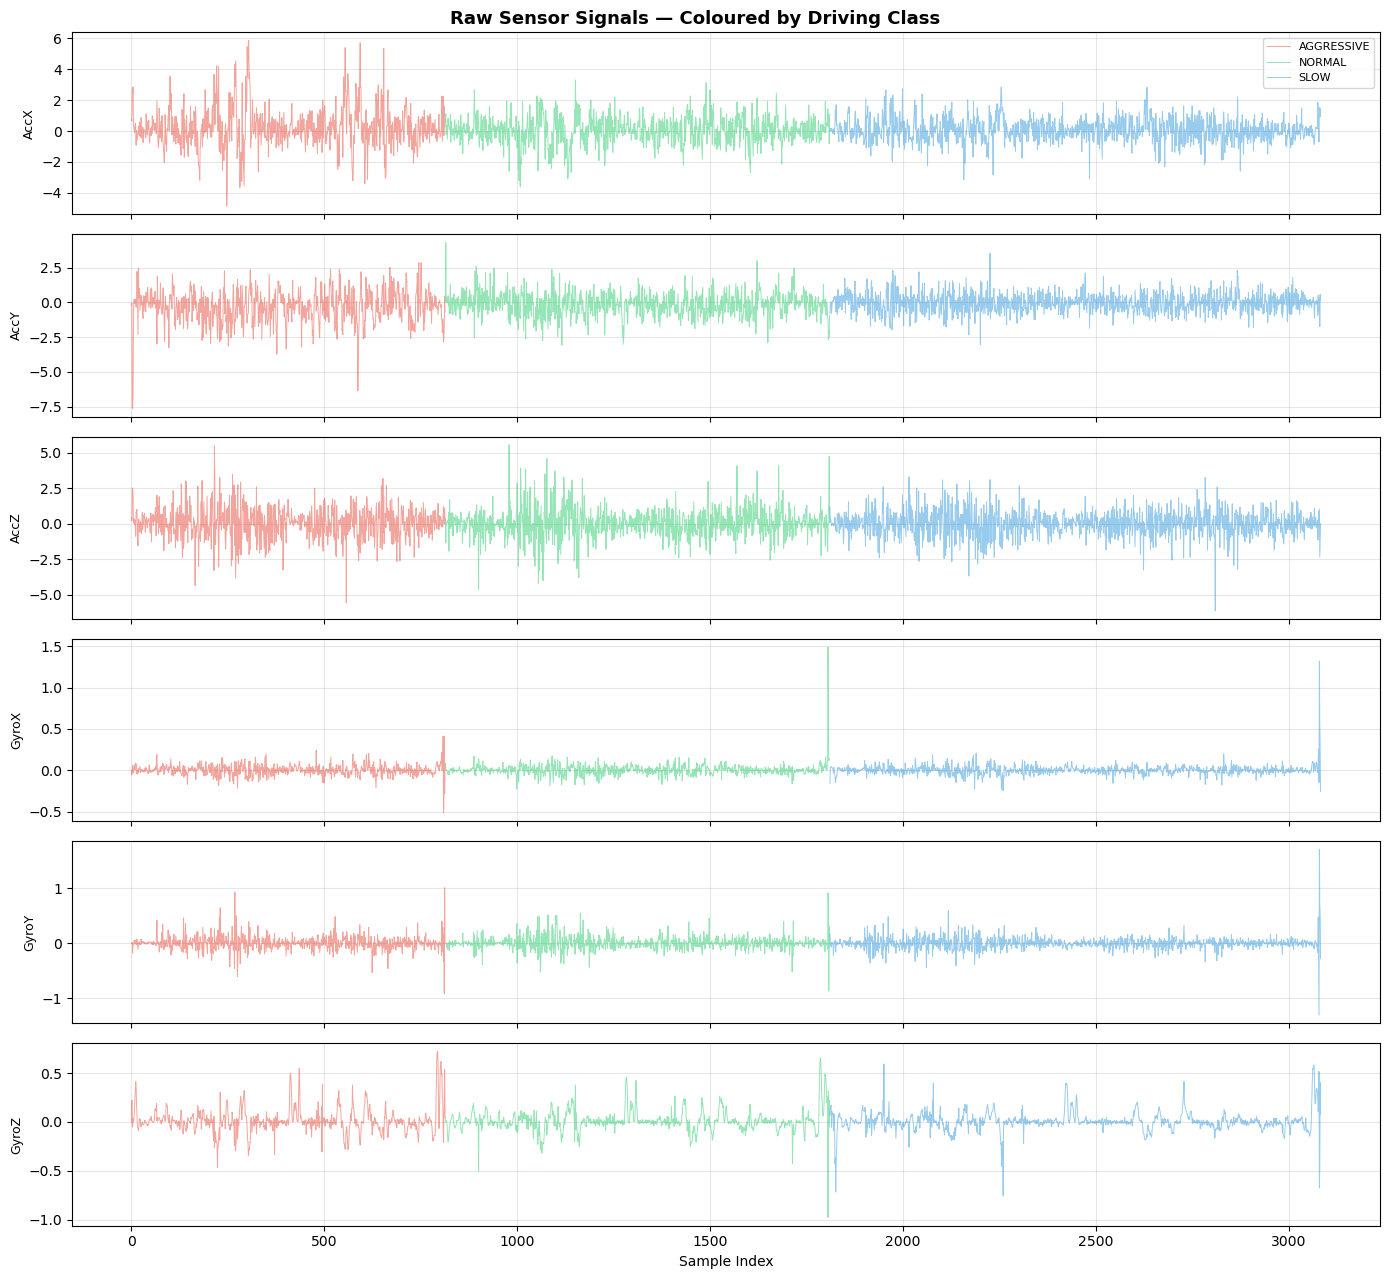

In [6]:
fig, axes = plt.subplots(len(SENSOR_COLS), 1, figsize=(14, 13), sharex=True)

for ax, col in zip(axes, SENSOR_COLS):
    for cls in df['Class'].unique():
        subset = df[df['Class'] == cls]
        ax.plot(subset.index, subset[col].values, alpha=0.5,
                color=CLASS_COLORS.get(cls, 'gray'), label=cls, linewidth=0.7)
    ax.set_ylabel(col, fontsize=9)
    ax.grid(alpha=0.3)
    if col == SENSOR_COLS[0]:
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel("Sample Index")
plt.suptitle("Raw Sensor Signals — Coloured by Driving Class", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_raw_signals.png", dpi=150, bbox_inches='tight')
plt.show()

### 1.5 — Distribution of each sensor per class (boxplot)

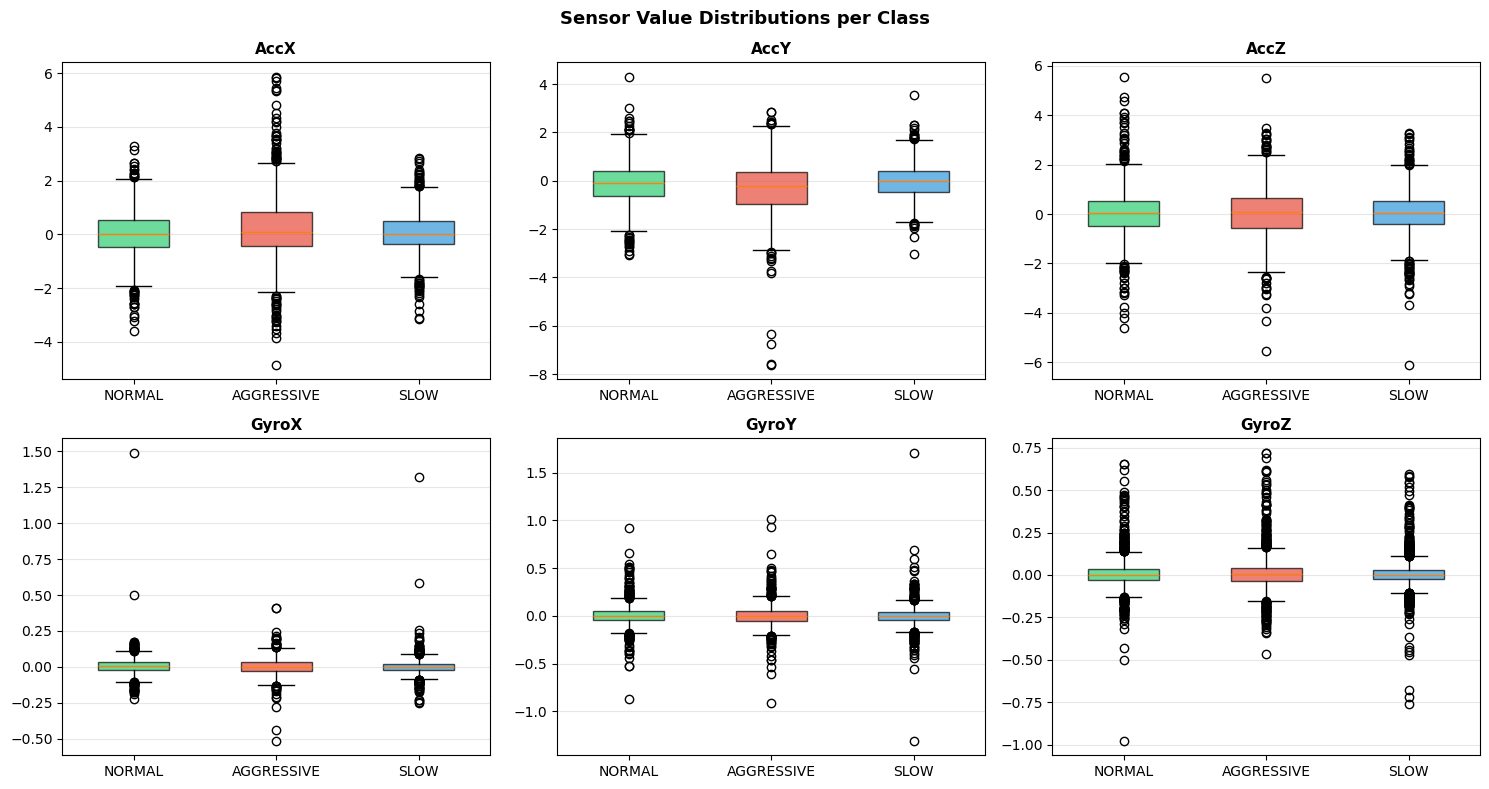


🔍 Observation: AGGRESSIVE driving shows higher variance in AccX/AccY
   SLOW driving has lower overall acceleration magnitudes


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), SENSOR_COLS):
    data   = [df[df['Class'] == cls][col].values for cls in CLASS_NAMES]
    colors = [CLASS_COLORS[c] for c in CLASS_NAMES]
    bp = ax.boxplot(data, patch_artist=True, labels=CLASS_NAMES, widths=0.5)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Sensor Value Distributions per Class", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_sensor_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Observation: AGGRESSIVE driving shows higher variance in AccX/AccY")
print("   SLOW driving has lower overall acceleration magnitudes")

### 1.6 — Correlation heatmap

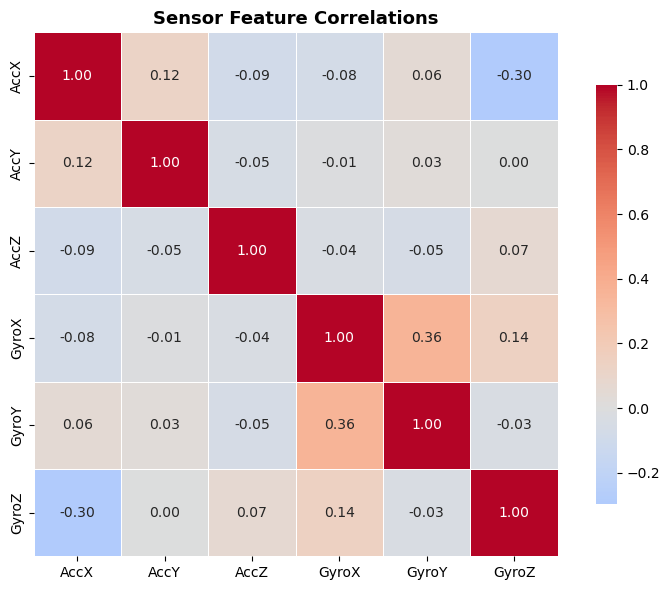

In [8]:
plt.figure(figsize=(8, 6))
corr = df[SENSOR_COLS].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title("Sensor Feature Correlations", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

### ✅ Exploration Complete

**Key findings:**
- 3 classes: NORMAL (997), AGGRESSIVE (814), SLOW (1273) — **imbalanced**
- AGGRESSIVE driving has higher **AccX/AccY variance** (lateral forces)
- SLOW driving has **low acceleration magnitude** overall
- Raw signals are noisy → we need **feature engineering** in the next step

**Next:** `02_Preprocessing_Feature_Engineering.ipynb`